## Task: Prepare this data for Machine Learning ##

- Import relevant Python libraries necessary for Python and Pandas analysis, as well as visualization 
- Import the CSV file NSMES1988_Dirty.csv file and create a new DataFrame for working with Pandas 
- Randomly Sample the DataFrame using the .sample() method - EDA
- Take Detailed Notes on any potential issues you see with the data
- Run the .describe() method, and Note any issues you see with the data - EDA
- Plot the dirty data - EDA
- Your goal here should be to gain insights into outliers, missing data, incorrect data, etc...
- If you see any of the above:
    - Provide Statistical evidence theses are indeed outliers
    - Ensure you provide p-values and interpret them correctly
 

### Clean the data - Data Wrangling ###
#### *"Treat your data like gold, covered in mud"; Remove as little information as possible, while ensuring you remove all the mud.* ####
##### Don't just pretty up the mud with your gold colored spray paint. #####
- Fix any issues with the dataset that you noted above (make sure to take detailed notes of your modifications)
- Data Imputation
- Data Integrity
- Remove Outliers
- Optimize Data Types
 

### Create new Features - Feature Engineering  (make sure to take detailed notes of your modifications ) ###
- Where Relevant perform,
    - Feature Scaling
    - Label, Ordinal, or 1Hot encode Categorical Features
    - (Ensure you properly handle Ordinal vs Nominal Categorical Features)
    - Feature Aggregation
    - Normalize and Standardize Features
    - Discretize (Bin) Features
 
- Prepare a detailed report and record your observations.

In [29]:
%pip install seaborn -q
%pip install pandas -q
%pip install scikit-learn -q

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as skl

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [30]:
from math import ceil

def scan_for_bad_data_cells(data: pd.DataFrame):
    print('Scanning dataframe for missing or bad data')
    # Compile a regex pattern for known bad strings
    # These can be ignored if values are accepted for that field
    regex_pattern = r'nan|unk|none|na|n/a|unknown|0|^$'
    # Create zero filled copy of passed df
    print(data.describe(include='all'))
    print(data.info(verbose=True, show_counts=True))
    counter_df = pd.DataFrame(0, index=np.arange(len(data)), columns=data.keys())
    for col in data.keys():
        if data[col].dtype == 'object':
            str_results = data[col].str.contains(regex_pattern, case=False, regex=True)
        else:
            str_results = data[col].isna() | data[col].isnull()
        results = data[col].isna() | data[col].isnull()
        full_results = str_results | results
        counter_df[col] = full_results.astype('Float32')
    print('Printout of scan results')
    counter_df.insert(0,'num_of_invalid_vals', counter_df.sum(axis=1, skipna=True, numeric_only=True))
    print(f'Invalid entries per index: {counter_df['num_of_invalid_vals']}')
    counter_df.set_index('num_of_invalid_vals', inplace=True)
    print(counter_df.tail(10).to_string())
    for col in counter_df:
        print(f'Number of invalid values in column {col}: {counter_df[col].sum()}')
    

    
def plot_all_data(data: pd.DataFrame, name: str='') -> None:
    print('Plotting all columns as hist and box plots')
    print(data.describe(include='all'))
    print(data.info(verbose=True, show_counts=True))
    col_len = len(data.keys())
    ax_rows = 2 * ceil(col_len / 3)
    print(f'Column Len = {col_len}')
    print(f'Axes Rows Amount = {ax_rows}')
    ax_cols = 3 if col_len >= 3 else col_len
    fig, axs = plt.subplots(ax_rows, ax_cols, figsize=[12, 8*ceil(ax_rows/2)])
    col_counter = 0
    row_counter = 0
    for col in data.keys():
        sns.histplot(data=data, x=col, ax=axs[row_counter,col_counter])
        
        sns.boxplot(data=data, x=col, ax=axs[row_counter+1,col_counter])
        col_counter += 1
        if col_counter > 2:
            col_counter = 0
            row_counter += 2
    fig.suptitle(name)

from scipy.stats import ttest_1samp
from pandas.api.types import is_numeric_dtype
def simple_ttest_all_data_columns(data: pd.DataFrame, alpha:float=0.05, samples:int=30):
    print('Starting T-tests...')
    for col in data:
        if not is_numeric_dtype(data[col]):
            print(f'Skipping {col} as dtype is not numeric')
            continue
        col_mean = data[col].mean()
        print(f'mean for {col}: {col_mean}')
        t_statistic, p_val = ttest_1samp(data[col], samples)
        print(f'p_value for {col}: {p_val}')
        if p_val < alpha:
            print(f'Reject null hypothesis for {col}')
        else:
            print(f'Fail to reject null hypothesis for {col}')
    print('')

import numpy as np
from statsmodels.stats.weightstats import ztest

def ztest_all_data_columns(data: pd.DataFrame, alpha:float=0.05, samples:int=50):
    print('Starting Z-tests')
    for col in data:
        if not is_numeric_dtype(data[col]):
            print(f'Skipping {col} as dtype is not numeric')
            continue
        col_mean = data[col].mean()
        print(f'mean for {col}: {col_mean}')
        
        ztest_score, p_val = ztest(data[col].sample(samples), value=col_mean, alternative='larger')
        print(f'p_value for {col}: {p_val}')
        if p_val < alpha:
            print(f'Reject null hypothesis for {col}')
        else:
            print(f'Fail to reject null hypothesis for {col}')
    print('')


## Dirty Data ##
 - First things first, the csv is not formatted as a csv
 - The csv is tab seperated instead of comma seperated and a quick replacement of tabs to commas should sort that first error out
    - This should work as there are no commas found in the file that would create problems from just mass replacement of tabs if commas were sprinkled in

[nmses1988_dirty.csv](nmses1988_dirty.csv) -> [nmses1988_dirty_tabs_replaced.csv](nmses1988_dirty_tabs_replaced.csv)

## Dirty Data pt.2 ##
- Print out and identify all bad data
- Sample the bad data set
- Describe the data, then plot it

In [31]:
dhdf = pd.read_csv('nmses1988_dirty_tabs_replaced.csv')
# Scan using custom function
scan_for_bad_data_cells(dhdf)

Scanning dataframe for missing or bad data
             visits      nvisits      ovisits     novisits    emergency  \
count   4186.000000  4186.000000  4186.000000  4186.000000  4186.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean       6.006928     1.615862     0.728141     0.550406     0.262303   
std        7.361932     5.308146     3.594853     4.120928     0.694748   
min       -2.000000    -1.000000    -1.000000    -1.000000     0.000000   
25%        1.000000     0.000000     0.000000     0.000000     0.000000   
50%        4.000000     0.000000     0.000000     0.000000     0.000000   
75%        8.000000     1.000000     0.000000     0.000000     0.000000   
max       94.000000   103.000000   139.000000   162.000000    12.000000   

           hospital   health      chronic     adl region

- Can see that we found 220 entries in each of the indexes that were missing values.
- The only indexes that had missing values were numeric ones, which make things easier on the imputation process later on

## Dirty Data pt.3 ##
- We can see that the invalid values spread across the dataframe are missing in the same amount across 10 different columns

Plotting all columns as hist and box plots
           visits    nvisits    ovisits   novisits  emergency   hospital  \
count   49.000000  49.000000  48.000000  49.000000  46.000000  47.000000   
unique        NaN        NaN        NaN        NaN        NaN        NaN   
top           NaN        NaN        NaN        NaN        NaN        NaN   
freq          NaN        NaN        NaN        NaN        NaN        NaN   
mean     5.163265   0.918367   0.875000   0.142857   0.217391   0.340426   
std      5.716741   2.370274   3.687962   0.456435   0.629393   0.759765   
min     -1.000000  -1.000000   0.000000   0.000000   0.000000   0.000000   
25%      1.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
50%      4.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
75%      8.000000   1.000000   0.000000   0.000000   0.000000   0.000000   
max     24.000000  11.000000  25.000000   2.000000   3.000000   3.000000   

         health    chronic     adl region   

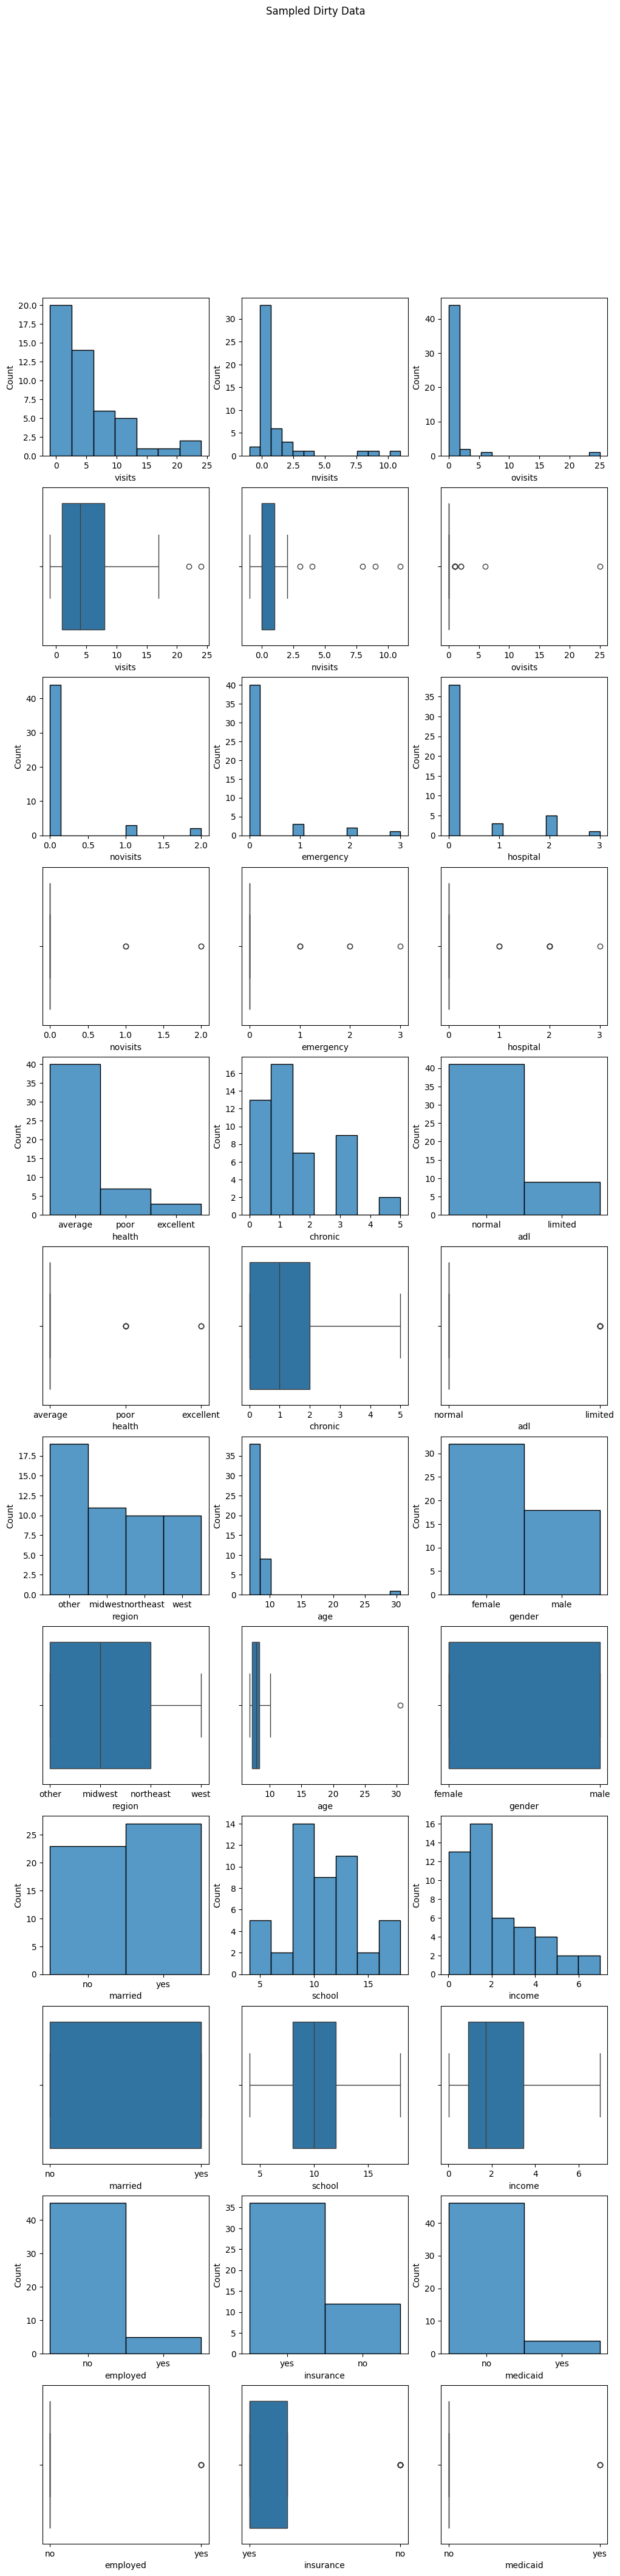

In [32]:
sample_df = dhdf.sample(n=50)

plot_all_data(sample_df, name='Sampled Dirty Data')

- Fill all the null values with NaN to give a baseline target for the imputation functions
- Change any data types that only have two values to a 0/1 or True/False dtype and recalculate
- Break up named data strings and one hot encode them to give them a value that can be used in feature enginerring
- Standardize/Normalize data
- Impute with KKnImupter to give a better data scaling across all the features and fit the normal distribution better
    - Multivariate imputation will help more with values that are of two values by looking at what similar samples have as those values


In [ ]:
dhdf.fillna(np.nan)

#Used from previous capstone project to remap data types
dhdf['age'] = dhdf['age'] * 10
dhdf['income'] = dhdf['income'] * 10000
dhdf.rename(columns={"visits":"num_physician_office_visits",
                             "nvisits":"num_non_physician_office_visits",
                             "ovisits":"num_outpatient_physician_office_visits",
                             "novisits":"num_outpatient_non_physician_office_visits",
                             "emergency":"num_emergency_visits",
                             "hospital":"num_hospital_stays",
                             "health":"self_reported_health_factor",
                             "chronic":"num_chronic_conds",
                             "adl":"daily_acty_limit_factor",
                             "school":"num_school_years",
                             "insurance":"has_priv_insurance",
                             "medicaid":"has_medicaid_coverage"}, inplace=True)
# Remap yes/no string to True/False boolean data
d = {'yes':True, 'no':False}
dhdf['married'] = dhdf['married'].map(d)
dhdf['has_priv_insurance'] = dhdf['has_priv_insurance'].map(d)
dhdf['has_medicaid_coverage'] = dhdf['has_medicaid_coverage'].map(d)
dhdf['employed'] = dhdf['employed'].map(d)
d = {'male':0, 'female':1}
dhdf['gender'] = dhdf['gender'].map(d)
# Remap most integer data as int8 as we won't be needing 64 bits of storage per unit (could maybe even go to int4 or int2)
dhdf['gender'] = dhdf['gender'].astype('Int8')
dhdf['num_school_years'] = dhdf['num_school_years'].astype('Int8')
dhdf['num_chronic_conds'] = dhdf['num_chronic_conds'].astype('Int8')
dhdf['num_physician_office_visits'] = dhdf['num_physician_office_visits'].astype('Int8')
dhdf['num_non_physician_office_visits'] = dhdf['num_non_physician_office_visits'].astype('Int8')
dhdf['num_outpatient_physician_office_visits'] = dhdf['num_outpatient_physician_office_visits'].astype('Int16')
dhdf['num_outpatient_non_physician_office_visits'] = dhdf['num_outpatient_non_physician_office_visits'].astype('Int16')

dhdf.convert_dtypes()

# Finished conversions

0       yes
1       yes
2        no
3       yes
4       yes
       ... 
4401    yes
4402     no
4403    yes
4404    yes
4405    yes
Name: married, Length: 4406, dtype: object
0       yes
1       yes
2        no
3       yes
4       yes
       ... 
4401    yes
4402     no
4403    yes
4404    yes
4405    yes
Name: married, Length: 4406, dtype: object


,num_physician_office_visits,num_non_physician_office_visits,num_outpatient_physician_office_visits,num_outpatient_non_physician_office_visits,num_emergency_visits,num_hospital_stays,self_reported_health_factor,num_chronic_conds,daily_acty_limit_factor,region,age,gender,married,num_school_years,income,employed,has_priv_insurance,has_medicaid_coverage
0,5,0,0,0,0,1,average,2,normal,other,71.181843,0,True,6,31134.299449,True,True,False
1,1,0,2,0,2,0,average,2,normal,other,76.787219,1,True,10,27746.118866,False,True,False
2,13,0,0,0,3,3,poor,4,limited,other,<NA>,1,False,10,<NA>,False,False,True
3,16,0,5,0,1,1,poor,2,limited,other,78.08326,0,True,3,9019.405753,False,True,False
4,3,0,0,0,<NA>,0,average,2,limited,other,81.330719,1,True,6,8298.446306,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4401,11,0,0,1,0,0,average,0,normal,other,87.109307,1,True,8,23055.892939,False,True,False
4402,12,0,0,0,0,<NA>,average,2,normal,other,<NA>,1,False,11,58190.457527,False,True,False
4403,10,0,20,0,1,1,average,<NA>,normal,other,75.169868,0,True,12,40016.073699,False,False,False
4404,16,1,<NA>,0,0,0,average,0,normal,other,68.116454,1,True,12,41069.922524,False,True,False


In [34]:
# One hot encode the strings series' "adl, "region, and "health"
# these indexes did not have missing or invalid data so we can one hot encode with the pandas get_dummies() function
# this also works as these are not nominal types and their order does no necessarily have meaning.
# That might be up for debate on health with poor, average, excellent but those terms are quite subjective and I find it easier to be consistent with the transformations

oh_adl = pd.get_dummies(dhdf['daily_acty_limit_factor'])
oh_reg = pd.get_dummies(dhdf['region'])
oh_hth = pd.get_dummies(dhdf['self_reported_health_factor'])

# drop columns that have been one hot encoded
dhdf = dhdf.drop(labels=['daily_acty_limit_factor', 'region', 'self_reported_health_factor'], axis=1)

### Dirt Data Scaled Plot ###

Plotting all columns as hist and box plots
       num_physician_office_visits  num_non_physician_office_visits  \
count                  4186.000000                      4186.000000   
mean                      0.083405                         0.025153   
std                       0.076687                         0.051040   
min                       0.000000                         0.000000   
25%                       0.031250                         0.009615   
50%                       0.062500                         0.009615   
75%                       0.104167                         0.019231   
max                       1.000000                         1.000000   

       num_outpatient_physician_office_visits  \
count                             4186.000000   
mean                                 0.012344   
std                                  0.025678   
min                                  0.000000   
25%                                  0.007143   
50%                    

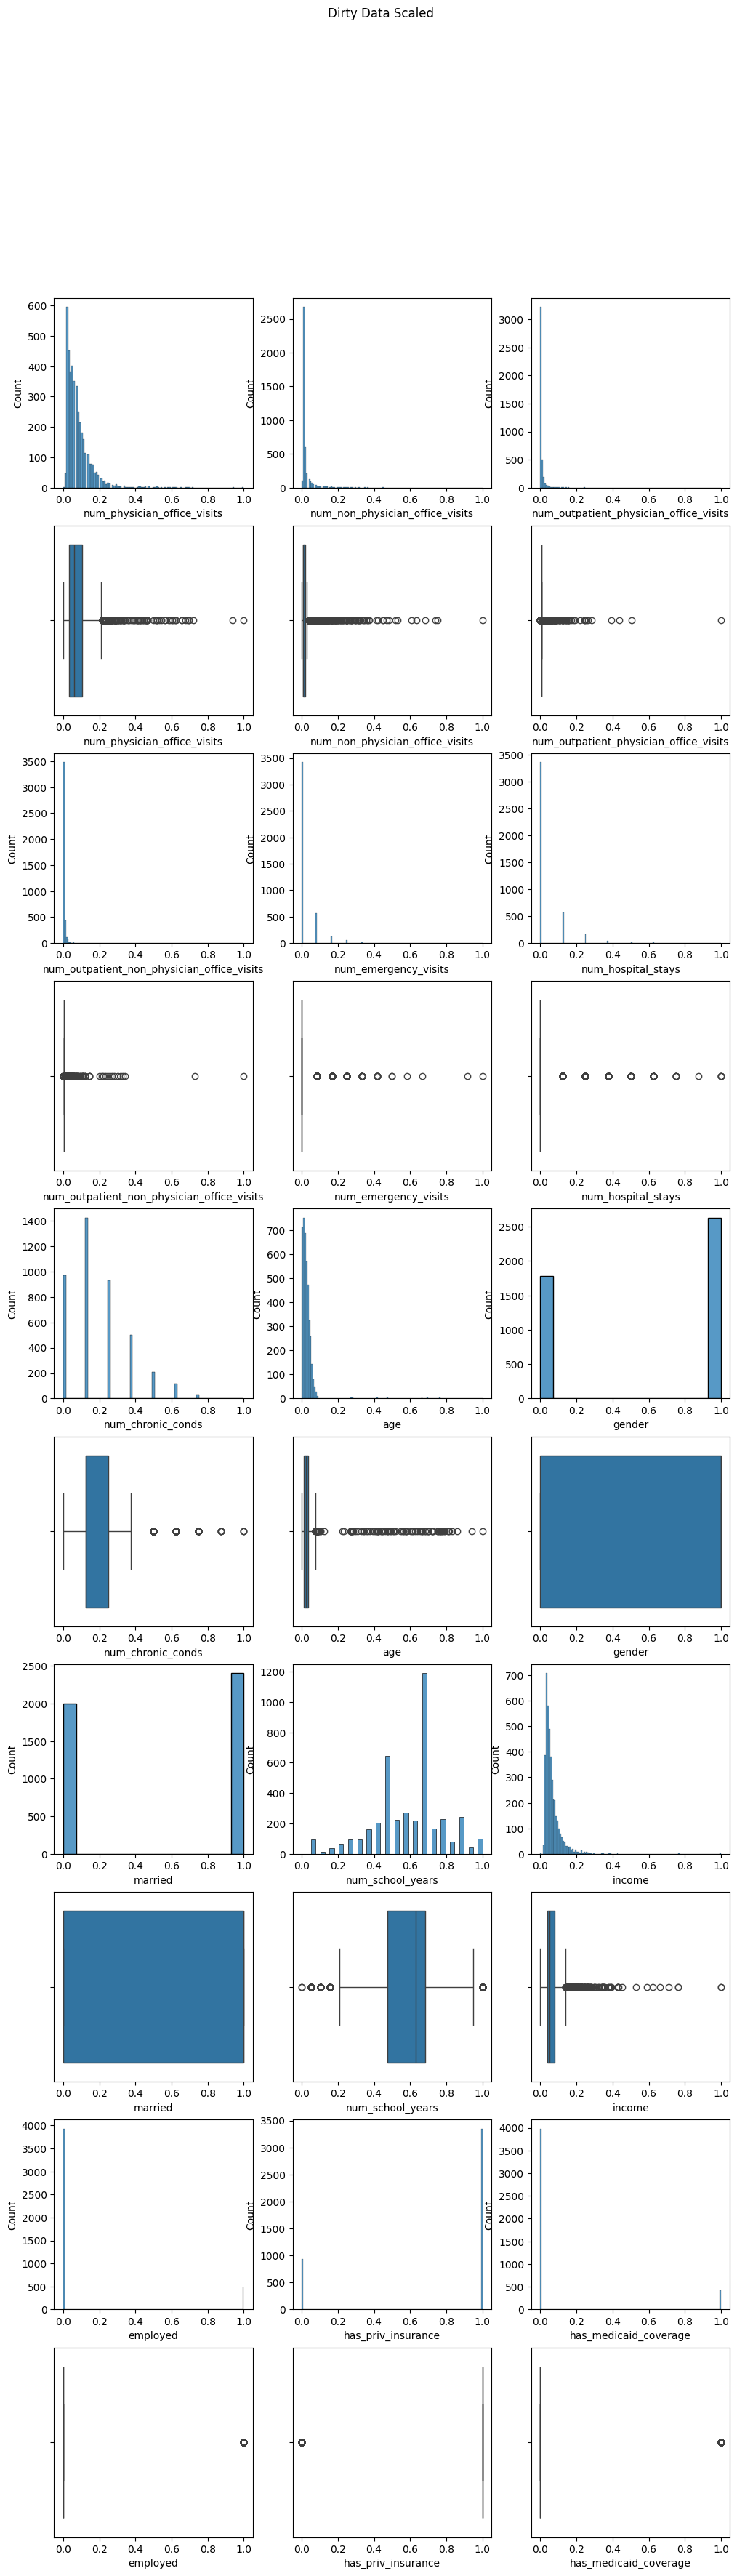

In [35]:
#Start normalization
# Since using one hot encoding, many of our new features are already on a scale of 0-1
# So minmax scaling seems to make the most sense to keep all our data evenly weighted
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
dhdf_scaled = pd.DataFrame(scaler.fit_transform(dhdf), columns=dhdf.columns)

# Now I can plot both the scaled and non-scaled version to see what similarites and differences there are
plot_all_data(dhdf_scaled, name='Dirty Data Scaled')


### Dirty Data Comparison Plot ###

Plotting all columns as hist and box plots
        num_physician_office_visits  num_non_physician_office_visits  \
count                        4186.0                           4186.0   
unique                         <NA>                             <NA>   
top                            <NA>                             <NA>   
freq                           <NA>                             <NA>   
mean                       6.006928                         1.615862   
std                        7.361932                         5.308146   
min                            -2.0                             -1.0   
25%                             1.0                              0.0   
50%                             4.0                              0.0   
75%                             8.0                              1.0   
max                            94.0                            103.0   

        num_outpatient_physician_office_visits  \
count                                   41

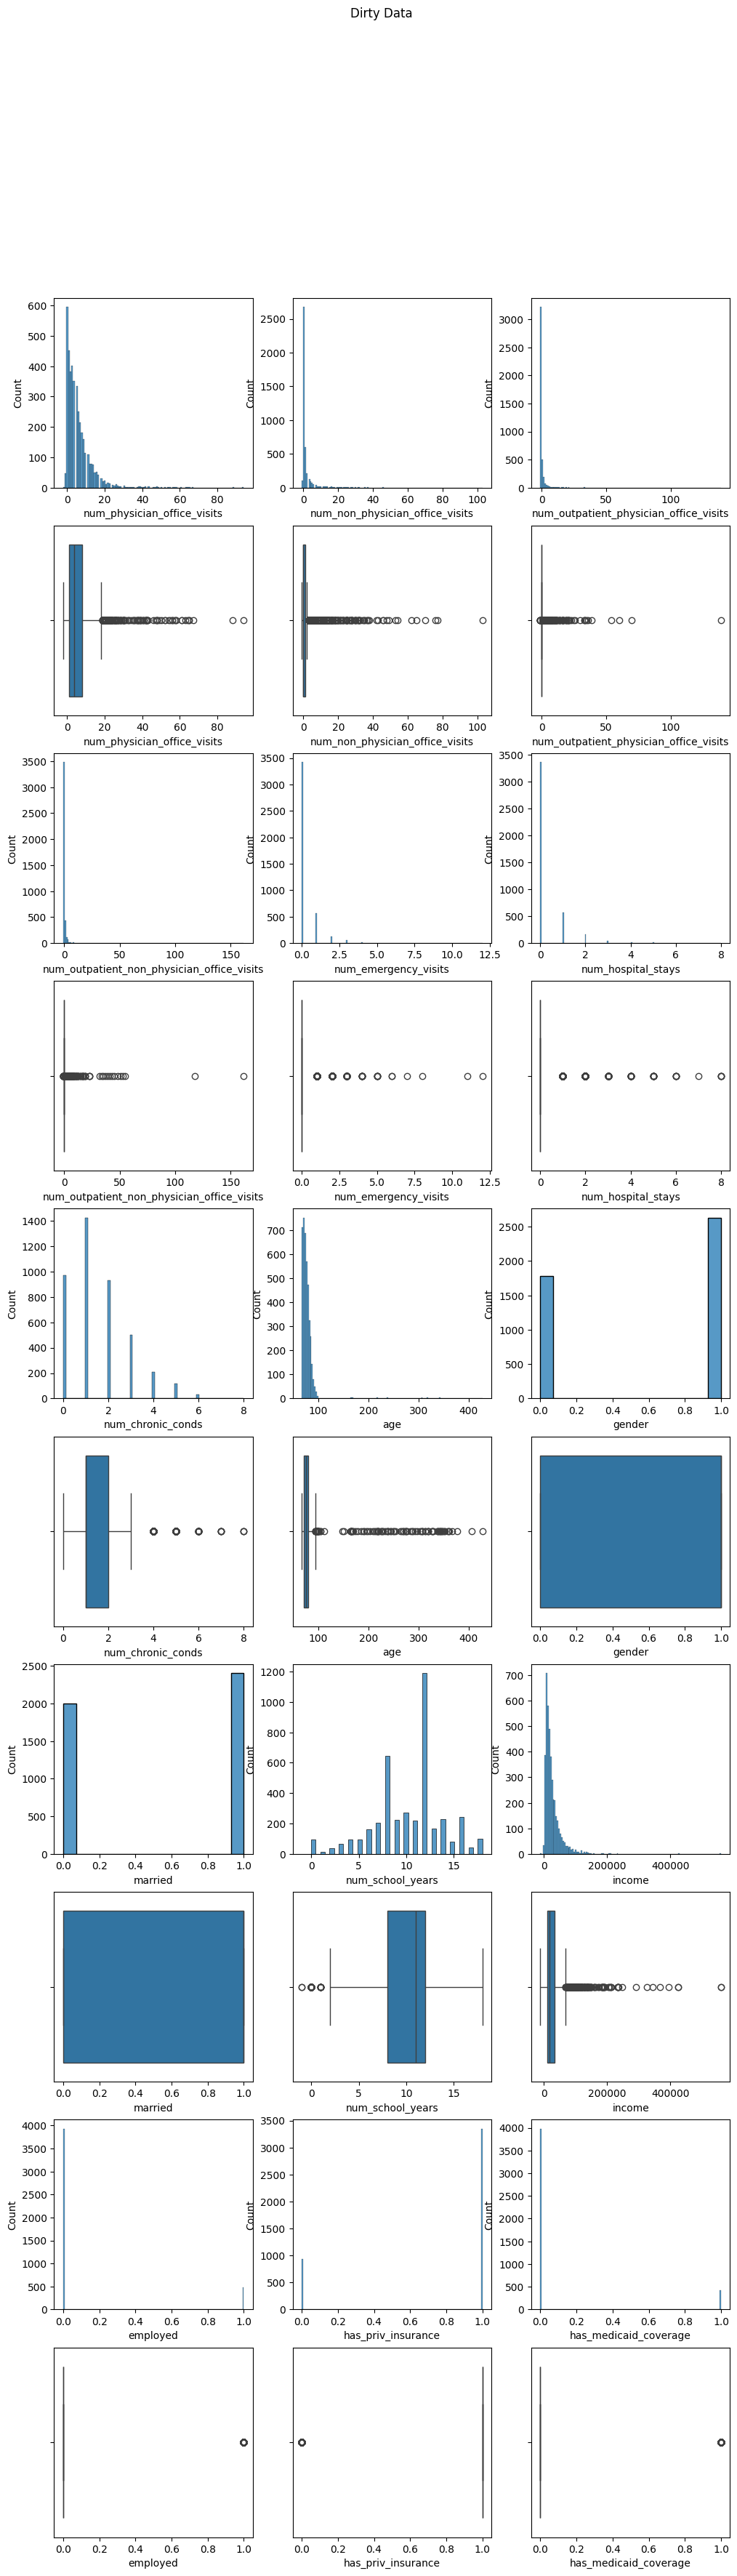

In [36]:
# New cell to break up plots better
plot_all_data(dhdf, name='Dirty Data')

### Imputing and Plotting ###
- Next I'll attempt to use the KNNImputer to fill in all my NaNs
- The data is now all scaled from 0 to 1 but much of it still looks very positively skewed
- I'm not sure if what I've done is fully correct, but I want to see it through at this point

Plotting all columns as hist and box plots
       num_physician_office_visits  num_non_physician_office_visits  \
count                  4406.000000                      4406.000000   
mean                      0.083043                         0.025079   
std                       0.075045                         0.049935   
min                       0.000000                         0.000000   
25%                       0.034722                         0.009615   
50%                       0.062500                         0.009615   
75%                       0.104167                         0.019231   
max                       1.000000                         1.000000   

       num_outpatient_physician_office_visits  \
count                             4406.000000   
mean                                 0.012297   
std                                  0.025072   
min                                  0.000000   
25%                                  0.007143   
50%                    

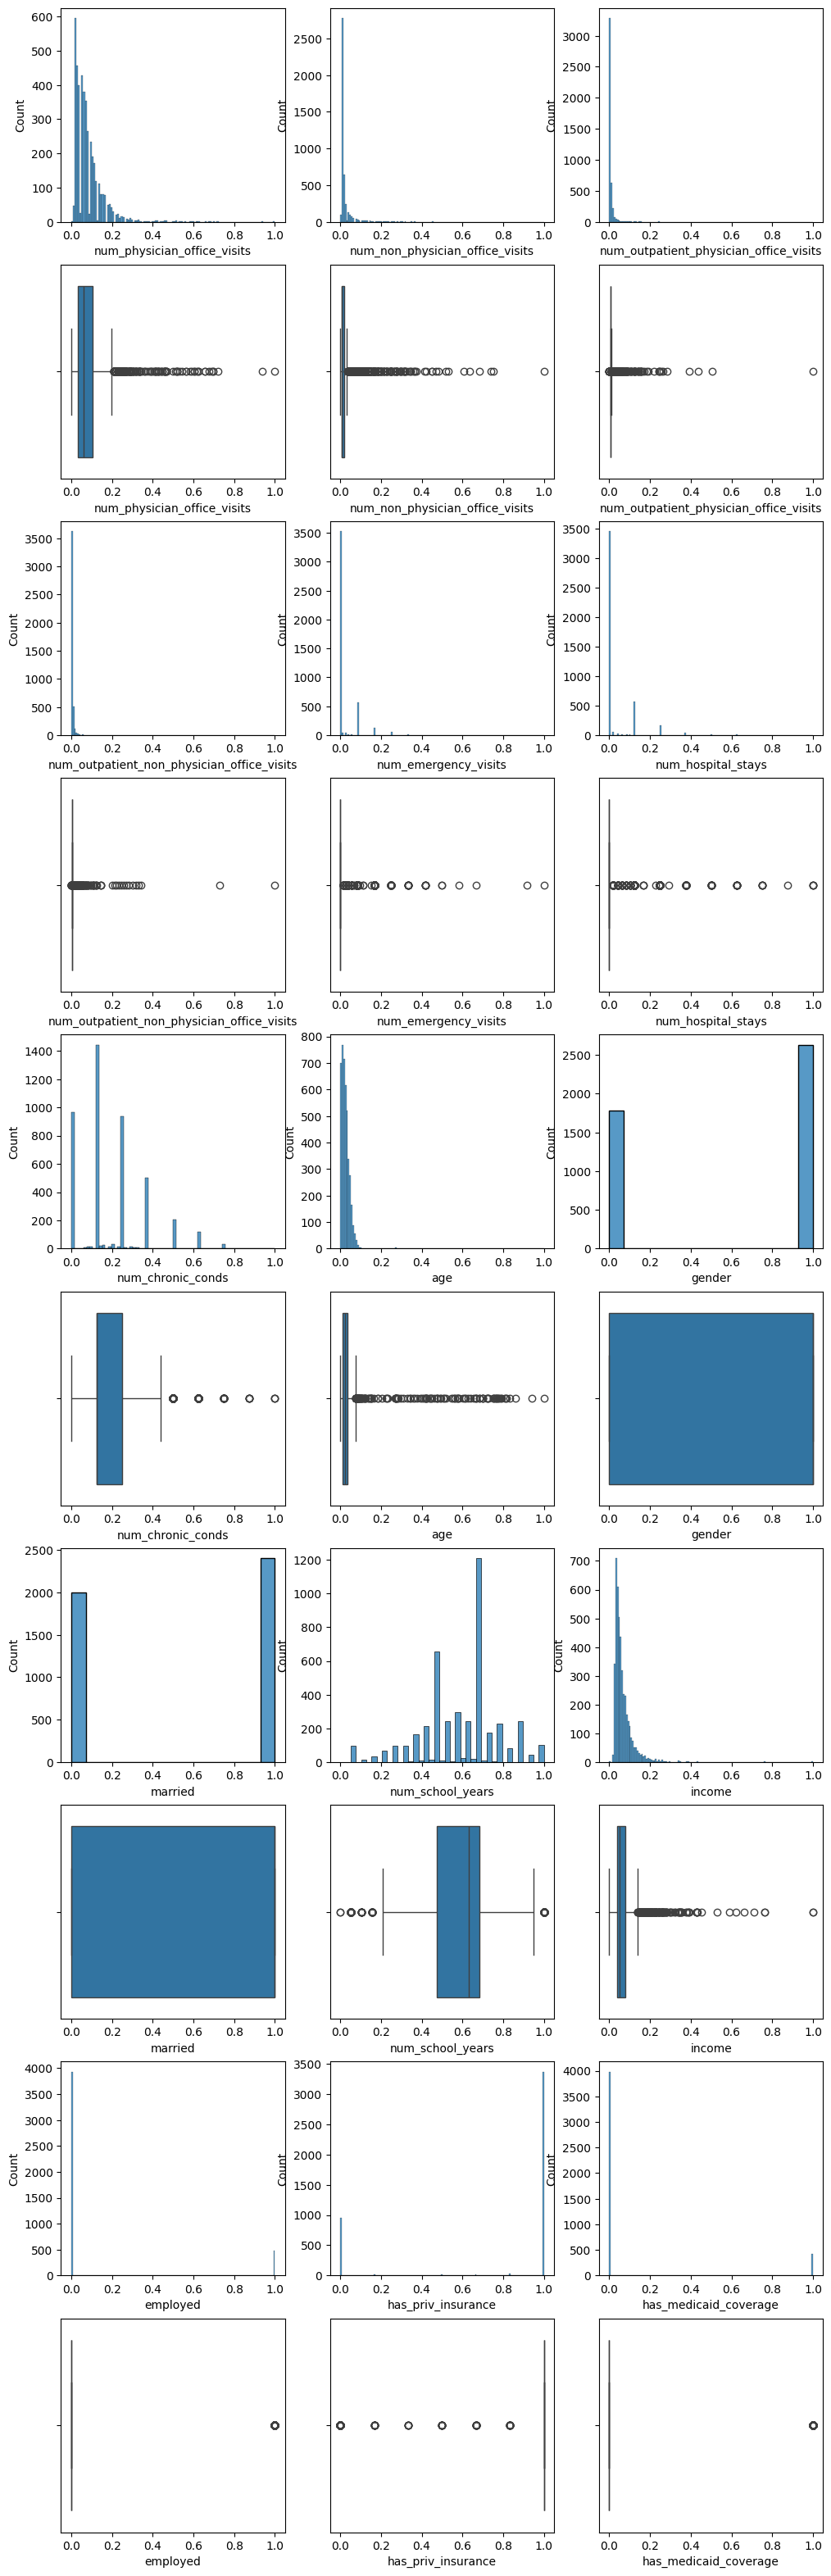

In [39]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=6, weights='uniform')
dhdf_imputed = dhdf_scaled = pd.DataFrame(imputer.fit_transform(dhdf_scaled), columns=dhdf_scaled.columns)

plot_all_data(dhdf_imputed)

### Feature Engineering ##
- Already scaled, labelled, encoded, standardized so now I am going to create new features using PolynomialFeatures
- This way it can be added and any useful feature creations can be retained without the need to try and figure out the best ones by hand

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# Use 3 degrees for all features
poly = PolynomialFeatures(degree=3)
dharr = poly.fit_transform(dhdf_imputed)
poly_feat_names = poly.get_feature_names_out()
dhdf_poly = pd.DataFrame(data=dharr, columns=poly_feat_names)

# Z-test all the new data columns
ztest_all_data_columns(dhdf_poly)


Starting Z-tests
mean for 1: 1.0
p_value for 1: nan
Fail to reject null hypothesis for 1
mean for num_physician_office_visits: 0.08304293072577798
p_value for num_physician_office_visits: 0.05295907913126845
Fail to reject null hypothesis for num_physician_office_visits
mean for num_non_physician_office_visits: 0.025079437131184747
p_value for num_non_physician_office_visits: 0.6442969672731054
Fail to reject null hypothesis for num_non_physician_office_visits
mean for num_outpatient_physician_office_visits: 0.012297354257181765
p_value for num_outpatient_physician_office_visits: 0.32927437296711637
Fail to reject null hypothesis for num_outpatient_physician_office_visits
mean for num_outpatient_non_physician_office_visits: 0.009482328893394117
p_value for num_outpatient_non_physician_office_visits: 0.6219430827613721
Fail to reject null hypothesis for num_outpatient_non_physician_office_visits
mean for num_emergency_visits: 0.021630856912291316
p_value for num_emergency_visits: 0.4307

f:\AI and Machine Learning course\FSA_devops\.venv\Lib\site-packages\statsmodels\stats\weightstats.py:748: RuntimeWarning: invalid value encountered in scalar divide
  zstat = (value1 - value2 - diff) / std_diff
f:\AI and Machine Learning course\FSA_devops\.venv\Lib\site-packages\statsmodels\stats\weightstats.py:748: RuntimeWarning: divide by zero encountered in scalar divide
  zstat = (value1 - value2 - diff) / std_diff


mean for num_non_physician_office_visits age gender: 0.0005585437751525938
p_value for num_non_physician_office_visits age gender: 0.7901477590522006
Fail to reject null hypothesis for num_non_physician_office_visits age gender
mean for num_non_physician_office_visits age married: 0.00046339835245128914
p_value for num_non_physician_office_visits age married: 0.9961199508004727
Fail to reject null hypothesis for num_non_physician_office_visits age married
mean for num_non_physician_office_visits age num_school_years: 0.0005581636565135453
p_value for num_non_physician_office_visits age num_school_years: 0.48581131270070954
Fail to reject null hypothesis for num_non_physician_office_visits age num_school_years
mean for num_non_physician_office_visits age income: 5.657208635591851e-05
p_value for num_non_physician_office_visits age income: 0.8343695287253083
Fail to reject null hypothesis for num_non_physician_office_visits age income
mean for num_non_physician_office_visits age employed

### End Report ###
- After adding in all the new feature from PolynomialFeatures there is a dearth of new p-values to checkout and verify
- This can give us clues as to which features are the most valuable to the overall dataset and which features are most correlated
- They can be removed if they fail to reject the null hypothesis as it shows a lack of useful correlation
- I think one of the ways to do this would be refining my functions tha do the testing so they can use the results to return a list of the feature names of low value features
- This would allow the use of df.drop() and the list to drop all the features in one go